In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("titles.csv")

df.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts300399,Five Came Back: The Reference Films,SHOW,This collection includes 12 World War II-era p...,1945,TV-MA,48,['documentation'],['US'],1.0,NaN,NaN,NaN,0.600,NaN
1,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,113,"['crime', 'drama']",['US'],NaN,tt0075314,8.3,795222.0,27.612,8.2
2,tm127384,Monty Python and the Holy Grail,MOVIE,"King Arthur, accompanied by his squire, recrui...",1975,PG,91,"['comedy', 'fantasy']",['GB'],NaN,tt0071853,8.2,530877.0,18.216,7.8
3,tm70993,Life of Brian,MOVIE,"Brian Cohen is an average young Jewish man, bu...",1979,R,94,['comedy'],['GB'],NaN,tt0079470,8.0,392419.0,17.505,7.8
4,tm190788,The Exorcist,MOVIE,12-year-old Regan MacNeil begins to adapt an e...,1973,R,133,['horror'],['US'],NaN,tt0070047,8.1,391942.0,95.337,7.7


In [2]:
df.shape #Datasetin olcusune baxmaq

(5806, 15)

In [4]:
df.columns #Sutun adlarini yoxlamaq

Index(['id', 'title', 'type', 'description', 'release_year',
       'age_certification', 'runtime', 'genres', 'production_countries',
       'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity',
       'tmdb_score'],
      dtype='object')

In [5]:
df.info() #Dataset haqqinda umumi melumat

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5806 entries, 0 to 5805
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    5806 non-null   object 
 1   title                 5805 non-null   object 
 2   type                  5806 non-null   object 
 3   description           5788 non-null   object 
 4   release_year          5806 non-null   int64  
 5   age_certification     3196 non-null   object 
 6   runtime               5806 non-null   int64  
 7   genres                5806 non-null   object 
 8   production_countries  5806 non-null   object 
 9   seasons               2047 non-null   float64
 10  imdb_id               5362 non-null   object 
 11  imdb_score            5283 non-null   float64
 12  imdb_votes            5267 non-null   float64
 13  tmdb_popularity       5712 non-null   float64
 14  tmdb_score            5488 non-null   float64
dtypes: float64(5), int64(

In [6]:
df.describe() #Statistik melumatlara baxmaq

,release_year,runtime,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
count,5806.000000,5806.000000,2047.000000,5283.000000,5.267000e+03,5712.000000,5488.000000
mean,2016.013434,77.643989,2.165608,6.533447,2.340719e+04,22.525660,6.818039
std,7.324883,39.474160,2.636207,1.160932,8.713432e+04,68.849177,1.171560
min,1945.000000,0.000000,1.000000,1.500000,5.000000e+00,0.009442,0.500000
25%,2015.000000,44.000000,1.000000,5.800000,5.210000e+02,3.155250,6.100000
50%,2018.000000,84.000000,1.000000,6.600000,2.279000e+03,7.478000,6.900000
75%,2020.000000,105.000000,2.000000,7.400000,1.014400e+04,17.775750,7.500000
max,2022.000000,251.000000,42.000000,9.600000,2.268288e+06,1823.374000,10.000000


In [7]:
df.isnull().sum() #Bos deyerleri tapmaq

id                         0
title                      1
type                       0
description               18
release_year               0
age_certification       2610
runtime                    0
genres                     0
production_countries       0
seasons                 3759
imdb_id                  444
imdb_score               523
imdb_votes               539
tmdb_popularity           94
tmdb_score               318
dtype: int64

In [2]:
df["imdb_score"] = df["imdb_score"].fillna(df["imdb_score"].mean())

df["imdb_votes"] = df["imdb_votes"].fillna(df["imdb_votes"].median())

df["age_certification"] = df["age_certification"].fillna("Unknown")
# Bos deyerleri doldurmaq

In [11]:
df.isnull().sum()

id                         0
title                      1
type                       0
description               18
release_year               0
age_certification          0
runtime                    0
genres                     0
production_countries       0
seasons                 3759
imdb_id                  444
imdb_score                 0
imdb_votes                 0
tmdb_popularity           94
tmdb_score               318
dtype: int64

In [3]:
df = df.dropna(subset=["title"]) #title (1 null)
df["description"] = df["description"].fillna("Unknown") #description 18 null
df["seasons"] = df["seasons"].fillna(0) 
df["imdb_id"] = df["imdb_id"].fillna("Unknown")
df["tmdb_popularity"] = df["tmdb_popularity"].fillna(df["tmdb_popularity"].mean())
df["tmdb_score"] = df["tmdb_score"].fillna(df["tmdb_score"].mean())

In [15]:
df.isnull().sum()

id                      0
title                   0
type                    0
description             0
release_year            0
age_certification       0
runtime                 0
genres                  0
production_countries    0
seasons                 0
imdb_id                 0
imdb_score              0
imdb_votes              0
tmdb_popularity         0
tmdb_score              0
dtype: int64

In [4]:
df["is_movie"] = df["type"].apply(lambda x: 1 if x == "MOVIE" else 0) #film ve seriali ayir
df.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,is_movie
0,ts300399,Five Came Back: The Reference Films,SHOW,This collection includes 12 World War II-era p...,1945,TV-MA,48,['documentation'],['US'],1.0,Unknown,6.533447,2279.0,0.600,6.818039,0
1,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,113,"['crime', 'drama']",['US'],0.0,tt0075314,8.300000,795222.0,27.612,8.200000,1
2,tm127384,Monty Python and the Holy Grail,MOVIE,"King Arthur, accompanied by his squire, recrui...",1975,PG,91,"['comedy', 'fantasy']",['GB'],0.0,tt0071853,8.200000,530877.0,18.216,7.800000,1
3,tm70993,Life of Brian,MOVIE,"Brian Cohen is an average young Jewish man, bu...",1979,R,94,['comedy'],['GB'],0.0,tt0079470,8.000000,392419.0,17.505,7.800000,1
4,tm190788,The Exorcist,MOVIE,12-year-old Regan MacNeil begins to adapt an e...,1973,R,133,['horror'],['US'],0.0,tt0070047,8.100000,391942.0,95.337,7.700000,1


In [5]:
df["movie_age"] = 2026 - df["release_year"] #nece il once 
df.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,is_movie,movie_age
0,ts300399,Five Came Back: The Reference Films,SHOW,This collection includes 12 World War II-era p...,1945,TV-MA,48,['documentation'],['US'],1.0,Unknown,6.533447,2279.0,0.600,6.818039,0,81
1,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,113,"['crime', 'drama']",['US'],0.0,tt0075314,8.300000,795222.0,27.612,8.200000,1,50
2,tm127384,Monty Python and the Holy Grail,MOVIE,"King Arthur, accompanied by his squire, recrui...",1975,PG,91,"['comedy', 'fantasy']",['GB'],0.0,tt0071853,8.200000,530877.0,18.216,7.800000,1,51
3,tm70993,Life of Brian,MOVIE,"Brian Cohen is an average young Jewish man, bu...",1979,R,94,['comedy'],['GB'],0.0,tt0079470,8.000000,392419.0,17.505,7.800000,1,47
4,tm190788,The Exorcist,MOVIE,12-year-old Regan MacNeil begins to adapt an e...,1973,R,133,['horror'],['US'],0.0,tt0070047,8.100000,391942.0,95.337,7.700000,1,53


In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["type_encoded"] = le.fit_transform(df["type"])
df["age_certification_encoded"] = le.fit_transform(df["age_certification"])
# categorical- i numeric- e cevir
df["type"].unique()

array(['SHOW', 'MOVIE'], dtype=object)

In [23]:
df.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,is_movie,movie_age,type_encoded,age_certification_encoded
0,ts300399,Five Came Back: The Reference Films,SHOW,This collection includes 12 World War II-era p...,1945,TV-MA,48,['documentation'],['US'],1.0,Unknown,6.533447,2279.0,0.600,6.818039,0,81,1,7
1,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,113,"['crime', 'drama']",['US'],0.0,tt0075314,8.300000,795222.0,27.612,8.200000,1,50,0,4
2,tm127384,Monty Python and the Holy Grail,MOVIE,"King Arthur, accompanied by his squire, recrui...",1975,PG,91,"['comedy', 'fantasy']",['GB'],0.0,tt0071853,8.200000,530877.0,18.216,7.800000,1,51,0,2
3,tm70993,Life of Brian,MOVIE,"Brian Cohen is an average young Jewish man, bu...",1979,R,94,['comedy'],['GB'],0.0,tt0079470,8.000000,392419.0,17.505,7.800000,1,47,0,4
4,tm190788,The Exorcist,MOVIE,12-year-old Regan MacNeil begins to adapt an e...,1973,R,133,['horror'],['US'],0.0,tt0070047,8.100000,391942.0,95.337,7.700000,1,53,0,4


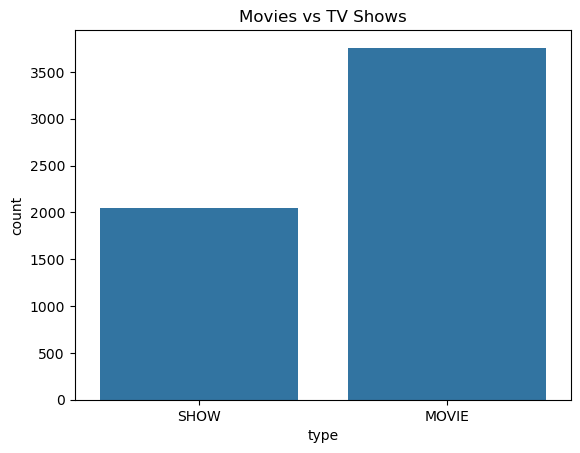

In [7]:
sns.countplot(x="type", data=df)
plt.title("Movies vs TV Shows")
plt.show()
# film ve serial sayi
# countplot

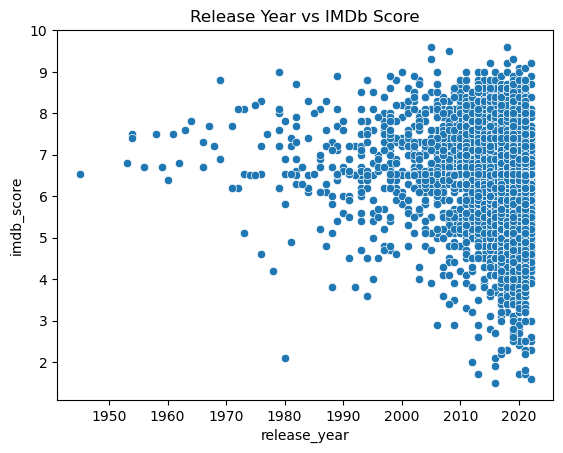

In [8]:
sns.scatterplot(x="release_year", y="imdb_score", data=df)
plt.title("Release Year vs IMDb Score")
plt.show()
# Release Year ve IMDb arasindaki elaqe
# Scatterplot

In [9]:
Q1 = df["imdb_score"].quantile(0.25)
Q3 = df["imdb_score"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
lower, upper

(np.float64(3.800000000000001), np.float64(9.399999999999999))

In [10]:
outliers = df[(df["imdb_score"] < lower) | (df["imdb_score"] > upper)]
outliers

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,is_movie,movie_age,type_encoded,age_certification_encoded
27,tm94651,Dostana,MOVIE,Vijay and Ravi are best friends (hence the nam...,1980,Unknown,161,"['drama', 'comedy', 'romance', 'action', 'crime']",['IN'],0.0,tt0080653,2.1,25.0,3.46000,4.900000,1,46,0,11
98,ts63001,High Risk,SHOW,High Risk is a program aired by the CBS televi...,1988,TV-PG,50,['comedy'],['US'],1.0,tt0094478,3.8,6.0,0.60000,6.818039,0,38,1,8
153,ts8570,Barney & Friends,SHOW,Barney & Friends is an American children's tel...,1992,TV-G,28,['family'],['US'],14.0,tt0144701,3.8,9955.0,46.95500,5.000000,0,34,1,6
235,tm118256,Yaar Gaddar,MOVIE,When his brother becomes involved in a deadly ...,1994,Unknown,147,"['crime', 'action', 'drama']",['IN'],0.0,tt0111780,3.6,142.0,2.75500,4.000000,1,32,0,11
243,ts4,Breaking Bad,SHOW,"When Walter White, a New Mexico chemistry teac...",2008,TV-MA,48,"['drama', 'thriller', 'crime']",['US'],5.0,tt0903747,9.5,1727694.0,337.41900,8.800000,0,18,1,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5757,tm1110212,Little Big Mouth,MOVIE,"Kicked out of his band and home, a playful gui...",2021,Unknown,94,"['romance', 'comedy', 'music']",['ZA'],0.0,tt14537540,3.8,170.0,35.42800,5.300000,1,5,0,11
5760,tm1038025,Slay,MOVIE,"In pursuit of both success and validation, a g...",2021,Unknown,93,['comedy'],['ZA'],0.0,tt14033300,3.3,101.0,1.47500,6.000000,1,5,0,11
5772,tm1099342,Devdas Brothers,MOVIE,"After their first heartbreaks, four jilted you...",2021,Unknown,99,['drama'],[],0.0,tt12478372,3.2,50.0,22.52566,6.818039,1,5,0,11
5778,tm1046969,Myriam Fares: The Journey,MOVIE,"From pregnancy to album preparations, Lebanese...",2021,Unknown,72,"['documentation', 'music']",['LB'],0.0,tt14773250,2.3,153.0,1.81400,6.818039,1,5,0,11


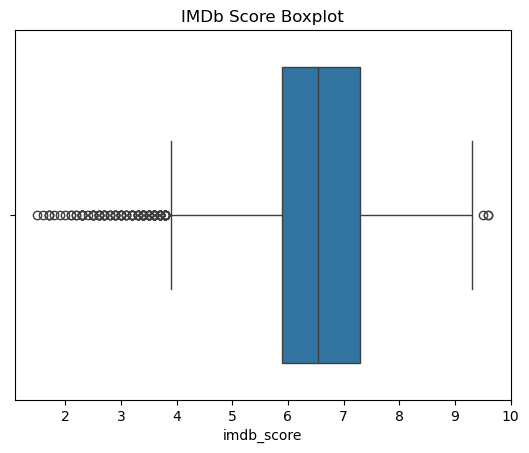

In [31]:
sns.boxplot(x=df["imdb_score"])
plt.title("IMDb Score Boxplot")
plt.show()
# boxplot
# outlier ve paylanma

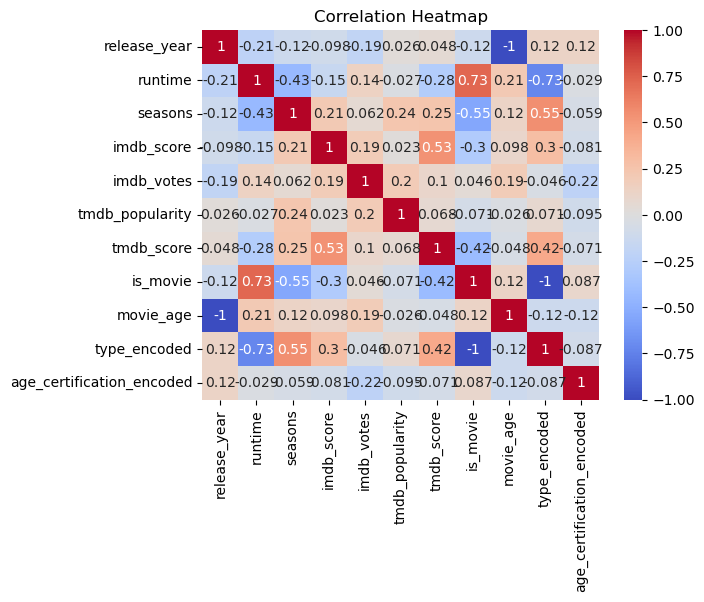

In [11]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()
#heatmap
#numericler arasindaki elage

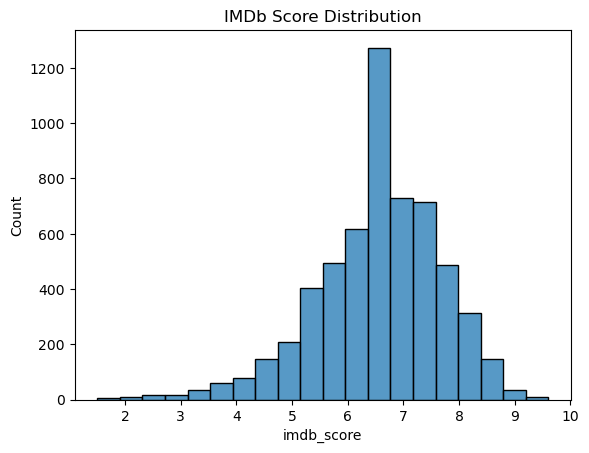

In [12]:
sns.histplot(df["imdb_score"], bins=20)
plt.title("IMDb Score Distribution")
plt.show()
#histogram
#MDb Score paylanmasi

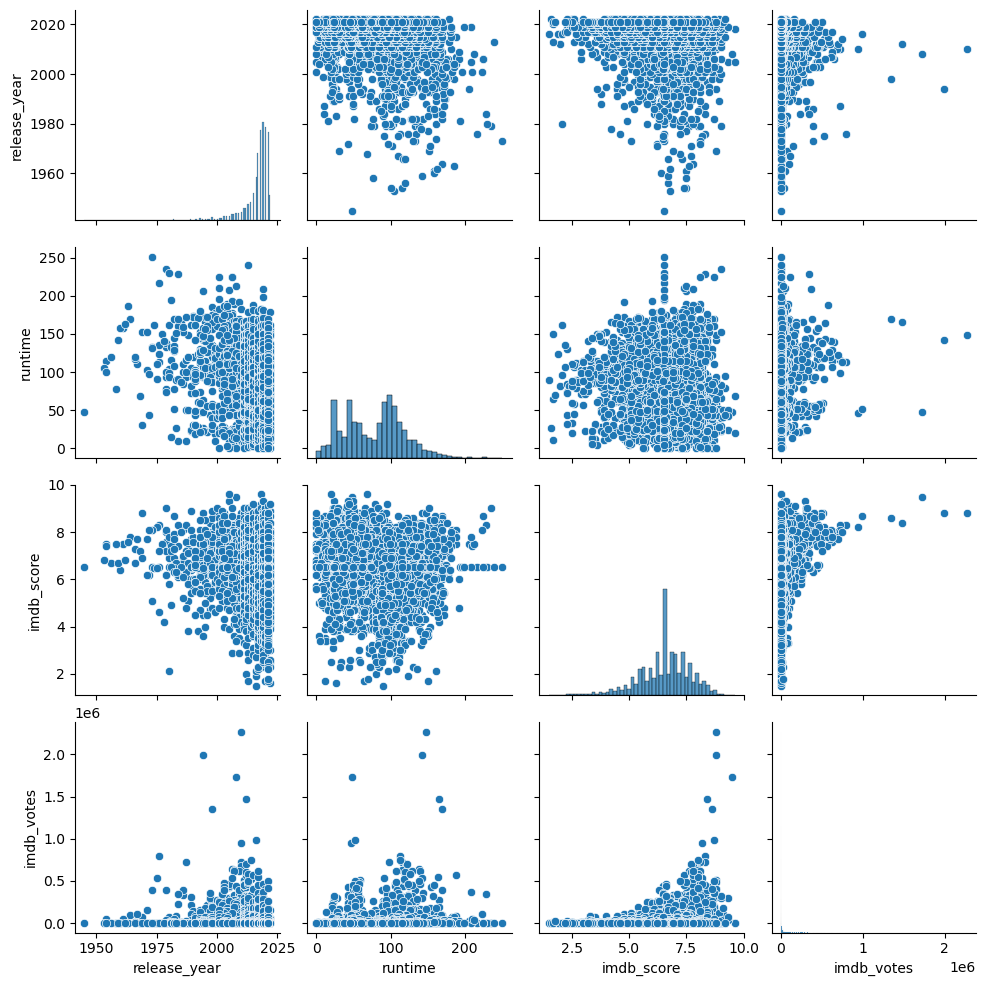

In [17]:
numeric_features = ['release_year', 'runtime', 'imdb_score', 'imdb_votes']
sns.pairplot(df[numeric_features])
plt.show()

In [32]:
import plotly.express as px
fig = px.scatter(
    data_frame=df,
    x='imdb_votes',
    y='imdb_score',
    color='type',
    hover_data=['title', 'release_year'],
    title='IMDb Score vs Votes (Popularity vs Rating)',
    labels={
        'imdb_votes': 'IMDb Votes',
        'imdb_score': 'IMDb Score',
        'type': 'Content Type'
    },
)

fig.update_layout(
    xaxis_type='log',
    title_x=0.5,
    template='plotly_dark',
    plot_bgcolor='rgba(0,0,0,0)'
)

fig.show(renderer='iframe')

In [33]:
title_per_year = df.groupby('release_year').size().reset_index(name='count')

fig = px.line(
    data_frame=title_per_year,
    x='release_year',
    y='count',
    title='Netflix Number of Titles released per Year',
    labels={'release_year': 'Release Year', 'count': 'Number of Titles'},
    markers=True
)

fig.update_layout(template='plotly_dark', title_x=0.5)
fig.show(renderer='iframe')

In [34]:
average_score_per_year = df.groupby('release_year')['imdb_score'].mean().reset_index()

fig = px.line(
    average_score_per_year,
    x='release_year',
    y='imdb_score',
    title='Average IMDb Score Per Year',
    labels={'release_year': 'Release Year', 'imdb_score': 'Avg IMDb Score'},
    markers=True
)

fig.update_layout(template='plotly_dark', title_x=0.5, yaxis=dict(range=[0, 10]))
fig.show(renderer='iframe')

In [35]:
avg_runtime_shows = df[df['type'] == 'MOVIE'].groupby('release_year')['runtime'].mean().reset_index()

fig = px.line(
    avg_runtime_shows,
    x='release_year',
    y='runtime',
    title='Average Runtime Per Year (Movies)',
    labels={'release_year': 'Release Year', 'runtime': 'Avg Runtime (mins)'},
    markers=True
)

fig.update_layout(template='plotly_dark', title_x=0.5)
fig.show(renderer='iframe')

In [36]:
score_by_cert = df.groupby('age_certification')['imdb_score'].mean().reset_index().dropna()

fig = px.bar(
    score_by_cert,
    x='age_certification',
    y='imdb_score',
    title='Netflix Average IMDb Score by Age Certification',
    labels={'age_certification': 'Age Certification', 'imdb_score': 'Avg IMDb Score'},
    color='imdb_score',
    color_continuous_scale='Viridis'
)

fig.update_layout(template='plotly_dark', title_x=0.5, yaxis=dict(range=[0, 10]))
fig.show(renderer='iframe')

In [37]:
votes_by_cert = df.groupby('age_certification')['imdb_votes'].mean().reset_index().dropna()

fig = px.bar(
    votes_by_cert,
    x='age_certification',
    y='imdb_votes',
    title='Netflix Average IBMD Votes by Age Certification',
    labels={'age_certification':'Age Certification', 'imdb_votes': 'Avg IMDB Vote'},
    color='imdb_votes',
    color_continuous_scale='Viridis'
)

fig.update_layout(template='plotly_dark', title_x=0.5)
fig.show(renderer='iframe')

In [48]:
import math
import ast

def plot_netflix_distributions(df_subset, plot_color='#E50914'):
    """
    Generates a grid of bar plots showing percentage distributions 
    for categorical, exploded list-like, and numeric columns.
    """
    plots_data = []
    
    #Standard Categorical Columns
    str_cols = ['type', 'age_certification']
    
    for col in str_cols:
        percentage = df_subset[col].value_counts() / df_subset['id'].nunique() * 100
        percentage = percentage.round(1).sort_values(ascending=False).head(5)
        plots_data.append((percentage, f'{col.capitalize().replace("_", " ")} (Overall)'))

    explode_cols = ['genres']
    
    for col in explode_cols:
        exploded_df = df_subset.copy()
        # Converting string representations of lists to actual Python lists
        exploded_df[col] = exploded_df[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and '[' in x else x)
        exploded_df = exploded_df.explode(col)
        exploded_df = exploded_df.replace('', np.nan).dropna(subset=[col])
        
        # Calculation of percentage
        percentage = exploded_df[col].value_counts() / df_subset['id'].nunique() * 100
        percentage = percentage.round(1).sort_values(ascending=False).head(5)
        plots_data.append((percentage, f'{col.capitalize().replace("_", " ")} (Exploded)'))

    #Numeric Columns
    shows_only = df_subset[df_subset['is_movie'] == 0]
    if not shows_only.empty:
        percentage = shows_only['seasons'].value_counts() / shows_only['id'].nunique() * 100
        percentage = percentage.round(1).sort_index(ascending=True).head(5)
        plots_data.append((percentage, 'Seasons (Shows Only)'))

    # --- Plotting Logic ---
    num_plots = len(plots_data)
    ncols = 3  # Setted to 3 columns for a cleaner layout
    nrows = math.ceil(num_plots / ncols)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows), layout='constrained')
    
    # Flatten axes array for easy iteration
    if num_plots == 1:
        axes_flat = [axes]
    elif nrows == 1 or ncols == 1:
        axes_flat = axes
    else:
        axes_flat = axes.flatten()

    for i, (percentage_series, title) in enumerate(plots_data):
        ax = axes_flat[i]
        percentage_series.plot(kind='bar', color=plot_color, ax=ax)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_ylabel('Percentage (%)', fontsize=10)
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=45, labelsize=10)
        ax.tick_params(axis='y', labelsize=10)

        # Add percentage labels directly on top of the bars
        for container in ax.containers:
            ax.bar_label(container, fmt='%.1f%%', fontsize=9, padding=3)
            
    for j in range(len(plots_data), len(axes_flat)):
        fig.delaxes(axes_flat[j])

    plt.show()
    return

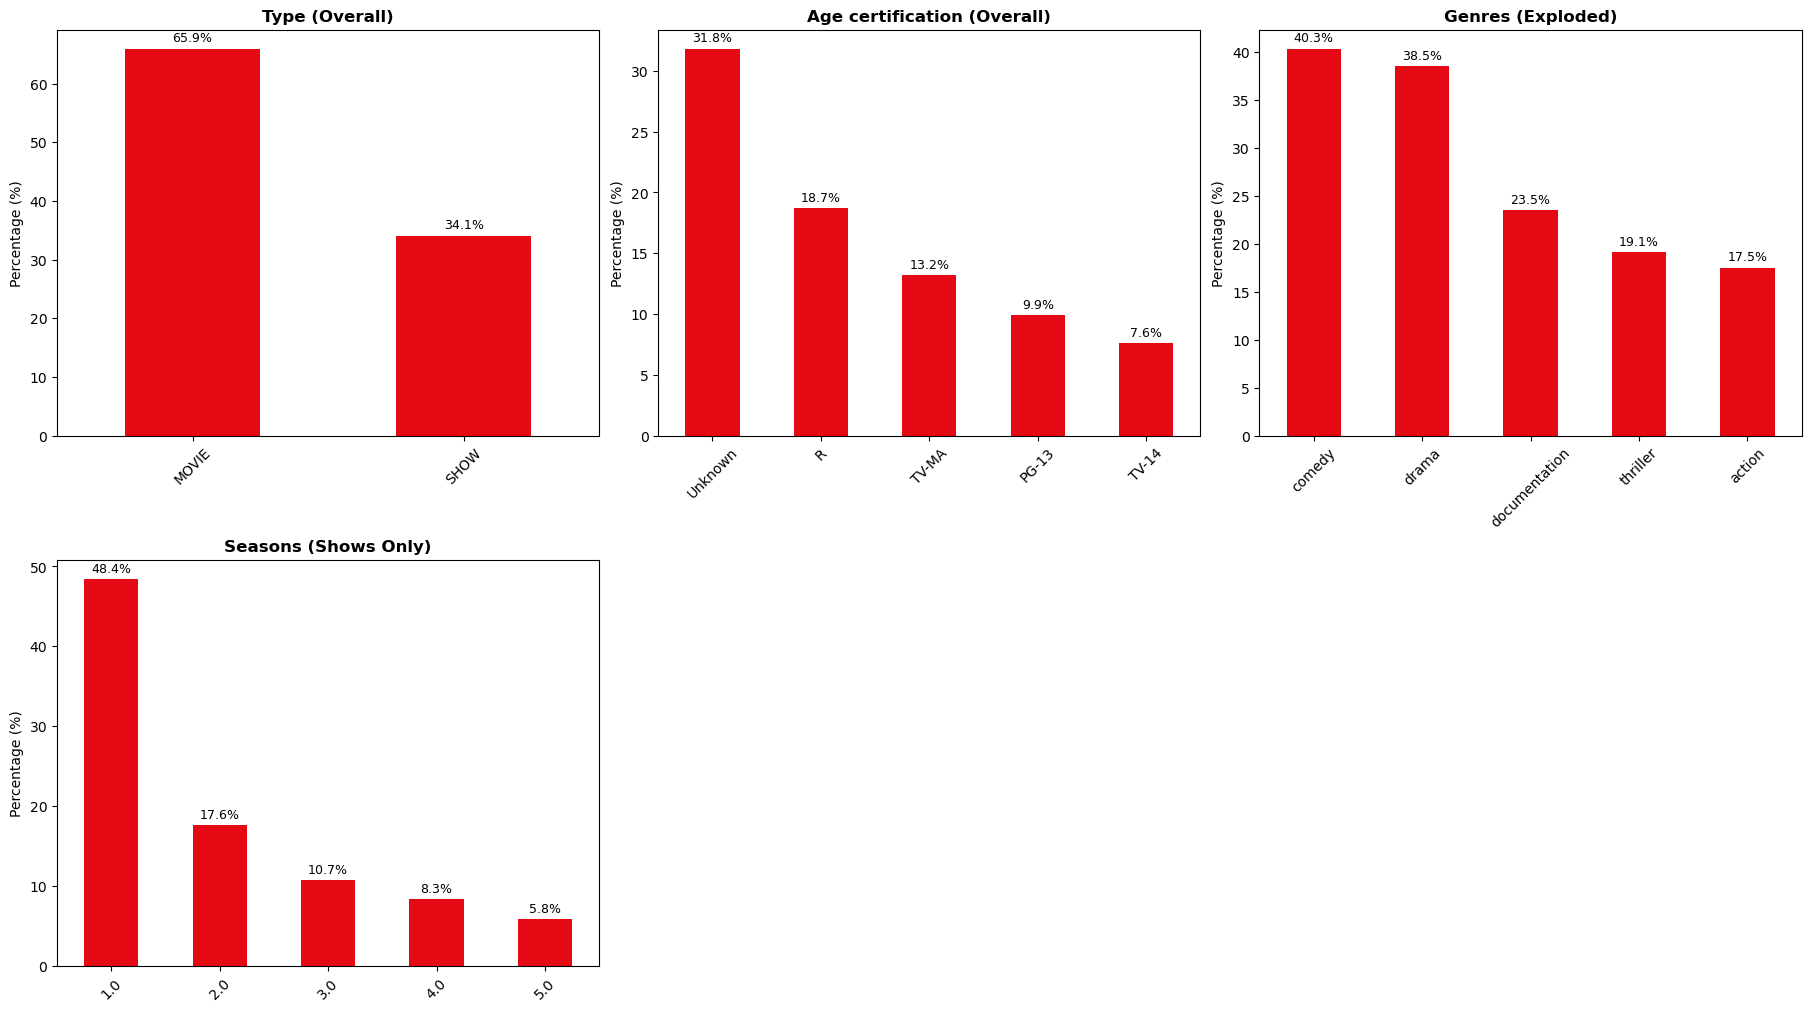

In [49]:
us_df = df[df['production_countries'].str.contains('US', na=False)]
plot_netflix_distributions(us_df)

In [44]:
 df["production_countries"].unique()

array(["['US']", "['GB']", "['US', 'GB']", "['JP']", "['EG']", "['DE']",
       "['IN']", '[]', "['DZ', 'EG']", "['LB']", "['FR', 'LB', 'CA']",
       "['IN', 'SU']", "['US', 'IT']", "['HK', 'US']", "['GB', 'US']",
       "['AR']", "['KW']", "['EG', 'FR']", "['FR', 'LB']", "['US', 'JP']",
       "['US', 'CA']", "['DE', 'US']", "['US', 'DE']", "['CA', 'US']",
       "['US', 'FR']", "['PE', 'US', 'BR']", "['IT', 'US', 'FR']",
       "['US', 'HK']", "['FR', 'IE', 'GB', 'DE']",
       "['GH', 'GB', 'US', 'BF', 'DE']", "['AR', 'ES']", "['FR']",
       "['MX']", "['AU']", "['CO']", "['BE', 'FR', 'NO', 'LB']",
       "['IT', 'LB', 'BE', 'FR']", "['US', 'FR', 'DE', 'PS']", "['TR']",
       "['CA']", "['GB', 'US', 'BS', 'CZ', 'DE']", "['GB', 'US', 'AU']",
       "['DE', 'ES', 'US', 'FR']", "['GB', 'US', 'AU', 'DE']",
       "['JP', 'US']", "['US', 'IS', 'GB']", "['DK']",
       "['NZ', 'JP', 'US']", "['US', 'CA', 'FR']", "['GB', 'US', 'DE']",
       "['US', 'DE', 'IT', 'GB']", "['CA', 'DE', 'US

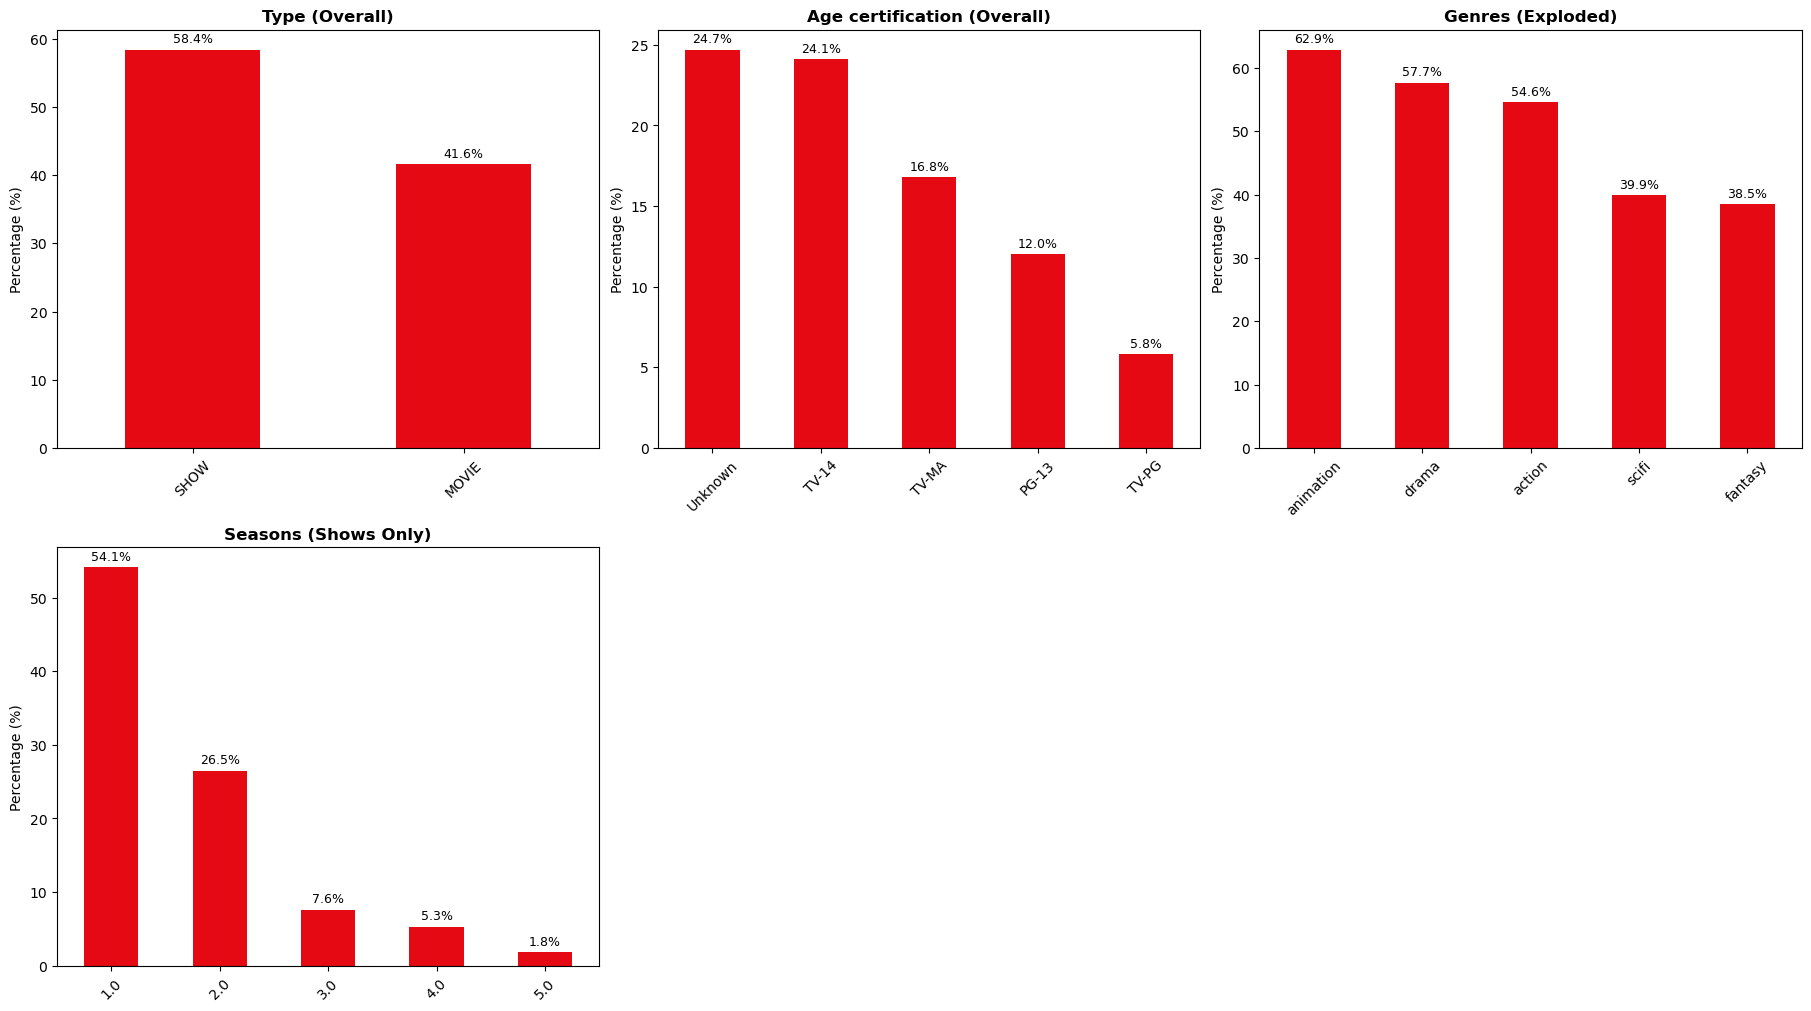

In [50]:
jp_df = df[df['production_countries'].str.contains('JP', na=False)]
plot_netflix_distributions(jp_df)

In [51]:
df_exploded = df.copy()

#Converting string representations of lists to actual Python lists
df_exploded['genres'] = df_exploded['genres'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) and '[' in x else x
)
df_exploded['production_countries'] = df_exploded['production_countries'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) and '[' in x else x
)

df_exploded = df_exploded.explode('genres').explode('production_countries')

# Cleaning any empty data
df_exploded = df_exploded.replace('', np.nan).dropna(subset=['genres', 'production_countries', 'imdb_votes'])

top_countries = df_exploded['production_countries'].value_counts().head(10).index
df_top_countries = df_exploded[df_exploded['production_countries'].isin(top_countries)]

#Group by Country and Genre to calculate Production Volume and Average Votes/Scores
genre_country_stats = df_top_countries.groupby(['production_countries', 'genres']).agg(
    production_count=('id', 'count'),          # How many titles did they make?
    avg_imdb_votes=('imdb_votes', 'mean')      # How much engagement did it get?
).reset_index()


min_titles_threshold = 10 

# Filter the dataframe to only include rows that meet the threshold
genre_country_stats = genre_country_stats[genre_country_stats['production_count'] >= min_titles_threshold]



fig = px.scatter(
    genre_country_stats,
    x='production_countries',
    y='genres',
    size='production_count',  
    color='avg_imdb_votes',    
    title=f'Genre Popularity by Top 10 Countries (Min {min_titles_threshold} Titles Produced)',
    labels={
        'production_countries': 'Production Country',
        'genres': 'Genre',
        'production_count': 'Total Titles Produced',
        'avg_imdb_votes': 'Average IMDB Votes'
    },
    color_continuous_scale='Viridis',
    size_max=45  
)

fig.update_layout(template='plotly_dark', title_x=0.5)
fig.show(renderer='iframe')